<a href="https://colab.research.google.com/github/Prudhvilakshman1112/GEN-AI/blob/main/EXP_7_Image_to_Image_Translation_using_CycleGAN_or_Pix2Pix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Cell 1: Dataset Download and Extraction
This cell handles the automated downloading and extraction of the edges2shoes dataset from the Berkeley servers. This dataset is approximately 2GB, as it contains thousands of high-resolution paired images where the left half is a sketch and the right half is the corresponding real photo.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import os
import urllib.request
import tarfile
from PIL import Image
import numpy as np

# Download configuration
dataset_name = "edges2shoes"
url = f"http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/{dataset_name}.tar.gz"
download_path = f"./{dataset_name}.tar.gz"

if not os.path.exists(f"./{dataset_name}"):
    print(f"Downloading {dataset_name} dataset (~2GB)... This may take a while.")
    urllib.request.urlretrieve(url, download_path)
    print("Download completed. Extracting...")
    with tarfile.open(download_path, "r:gz") as tar:
        tar.extractall(path="./")
    print(f"Dataset extracted successfully.")
else:
    print(f"Dataset already exists.")

Download completed. Extracting...


/tmp/ipykernel_2192/1972679114.py:24: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path="./")


Dataset extracted successfully.


#Cell 2: Custom Paired Dataset Class
Pix2Pix requires "paired" data. In this dataset, the input and target are side-by-side in a single image file. This cell defines a custom PyTorch Dataset class that opens each file, crops it down the middle to separate the Edge Map (Input A) from the Real Photo (Target B), and applies normalization.

In [ ]:
class PairedImageDataset(torch.utils.data.Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.files = sorted(os.listdir(root))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        img_path = os.path.join(self.root, self.files[index])
        image = Image.open(img_path).convert("RGB")
        w, h = image.size
        w2 = int(w / 2)

        # Split: left = edge (input A), right = real photo (target B)
        input_A = image.crop((0, 0, w2, h))
        target_B = image.crop((w2, 0, w, h))

        if self.transform:
            input_A = self.transform(input_A)
            target_B = self.transform(target_B)

        return input_A, target_B

# Transforms and Loader
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = PairedImageDataset(root="./edges2shoes/train", transform=transform)
dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)

print(f"Ready: {len(train_dataset)} image pairs loaded.")

Ready: 49825 image pairs loaded.


#Cell 3: Generator and Discriminator Architecture
This cell defines the two competing networks:

1)The Generator: An Encoder-Decoder that takes a sketch and tries to reconstruct a shoe. (While Pix2Pix traditionally uses a U-Net with skip connections, this demo uses a simplified version).

2)The Discriminator: A "PatchGAN" style critic. Instead of looking at the whole image, it looks at overlapping patches to determine if the local textures look real or fake.

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            # Final layer uses Tanh to match normalized input range [-1, 1]
            nn.ConvTranspose2d(64, 3, 4, 2, 1), nn.Tanh()
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # Takes 6 channels: Concatenated Input A (Edge) and Output B (Shoe)
            nn.Conv2d(6, 64, 4, 2, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, True),
            nn.Conv2d(256, 1, 4, 1, 1), nn.Sigmoid()
        )
    def forward(self, input_A, output_B):
        return self.model(torch.cat([input_A, output_B], dim=1))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
G, D = Generator().to(device), Discriminator().to(device)

#Cell 4: Losses and Training Loop
In Pix2Pix, we use two losses for the Generator:

GAN Loss: To make the image look like a real shoe.

L1 Loss: To ensure the generated shoe stays structurally close to the input sketch.
The lambda_L1 parameter (set to 100) weighs the L1 loss heavily to prevent the generator from being too "creative" and ignoring the edges.

In [ ]:
optimizer_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

criterion_GAN = nn.BCELoss()
criterion_L1 = nn.L1Loss()
lambda_L1 = 100

print("Starting Pix2Pix training...")
for epoch in range(5):
    for i, (real_A, real_B) in enumerate(dataloader):
        real_A, real_B = real_A.to(device), real_B.to(device)

        # --- Train Discriminator ---
        fake_B = G(real_A)
        pred_real = D(real_A, real_B)
        pred_fake = D(real_A, fake_B.detach())
        loss_D = (criterion_GAN(pred_real, torch.ones_like(pred_real)) +
                  criterion_GAN(pred_fake, torch.zeros_like(pred_fake))) * 0.5

        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

        # --- Train Generator ---
        pred_fake = D(real_A, fake_B)
        loss_G_GAN = criterion_GAN(pred_fake, torch.ones_like(pred_fake))
        loss_G_L1 = criterion_L1(fake_B, real_B)
        loss_G = loss_G_GAN + (lambda_L1 * loss_G_L1)

        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

        if i % 200 == 0:
            print(f"Epoch [{epoch+1}/5] Step [{i}/{len(dataloader)}] D_loss: {loss_D.item():.4f} G_loss: {loss_G.item():.4f}")

Starting Pix2Pix training...
Epoch [1/5] Step [0/3115] D_loss: 0.7114 G_loss: 95.0841
Epoch [1/5] Step [200/3115] D_loss: 0.3067 G_loss: 31.3977
Epoch [1/5] Step [400/3115] D_loss: 0.1147 G_loss: 36.2709
Epoch [1/5] Step [600/3115] D_loss: 0.0518 G_loss: 40.3481
Epoch [1/5] Step [800/3115] D_loss: 0.0855 G_loss: 29.9157
Epoch [1/5] Step [1000/3115] D_loss: 0.0251 G_loss: 37.0442
Epoch [1/5] Step [1200/3115] D_loss: 0.0249 G_loss: 34.4569
Epoch [1/5] Step [1400/3115] D_loss: 0.0658 G_loss: 32.7495
Epoch [1/5] Step [1600/3115] D_loss: 0.0073 G_loss: 34.6496
Epoch [1/5] Step [1800/3115] D_loss: 0.0121 G_loss: 31.8477
Epoch [1/5] Step [2000/3115] D_loss: 0.0696 G_loss: 36.7000
Epoch [1/5] Step [2200/3115] D_loss: 0.0118 G_loss: 33.4158
Epoch [1/5] Step [2400/3115] D_loss: 0.0027 G_loss: 36.6151
Epoch [1/5] Step [2600/3115] D_loss: 0.3812 G_loss: 31.0871
Epoch [1/5] Step [2800/3115] D_loss: 0.0506 G_loss: 28.6666
Epoch [1/5] Step [3000/3115] D_loss: 0.0294 G_loss: 32.9868
Epoch [2/5] Step [

#Cell 5: Visualizing Results
Finally, we run the model in evaluation mode. This cell takes fresh input edges from the dataloader and displays a three-way comparison: the original sketch, the model's generated shoe, and the actual ground-truth photo.

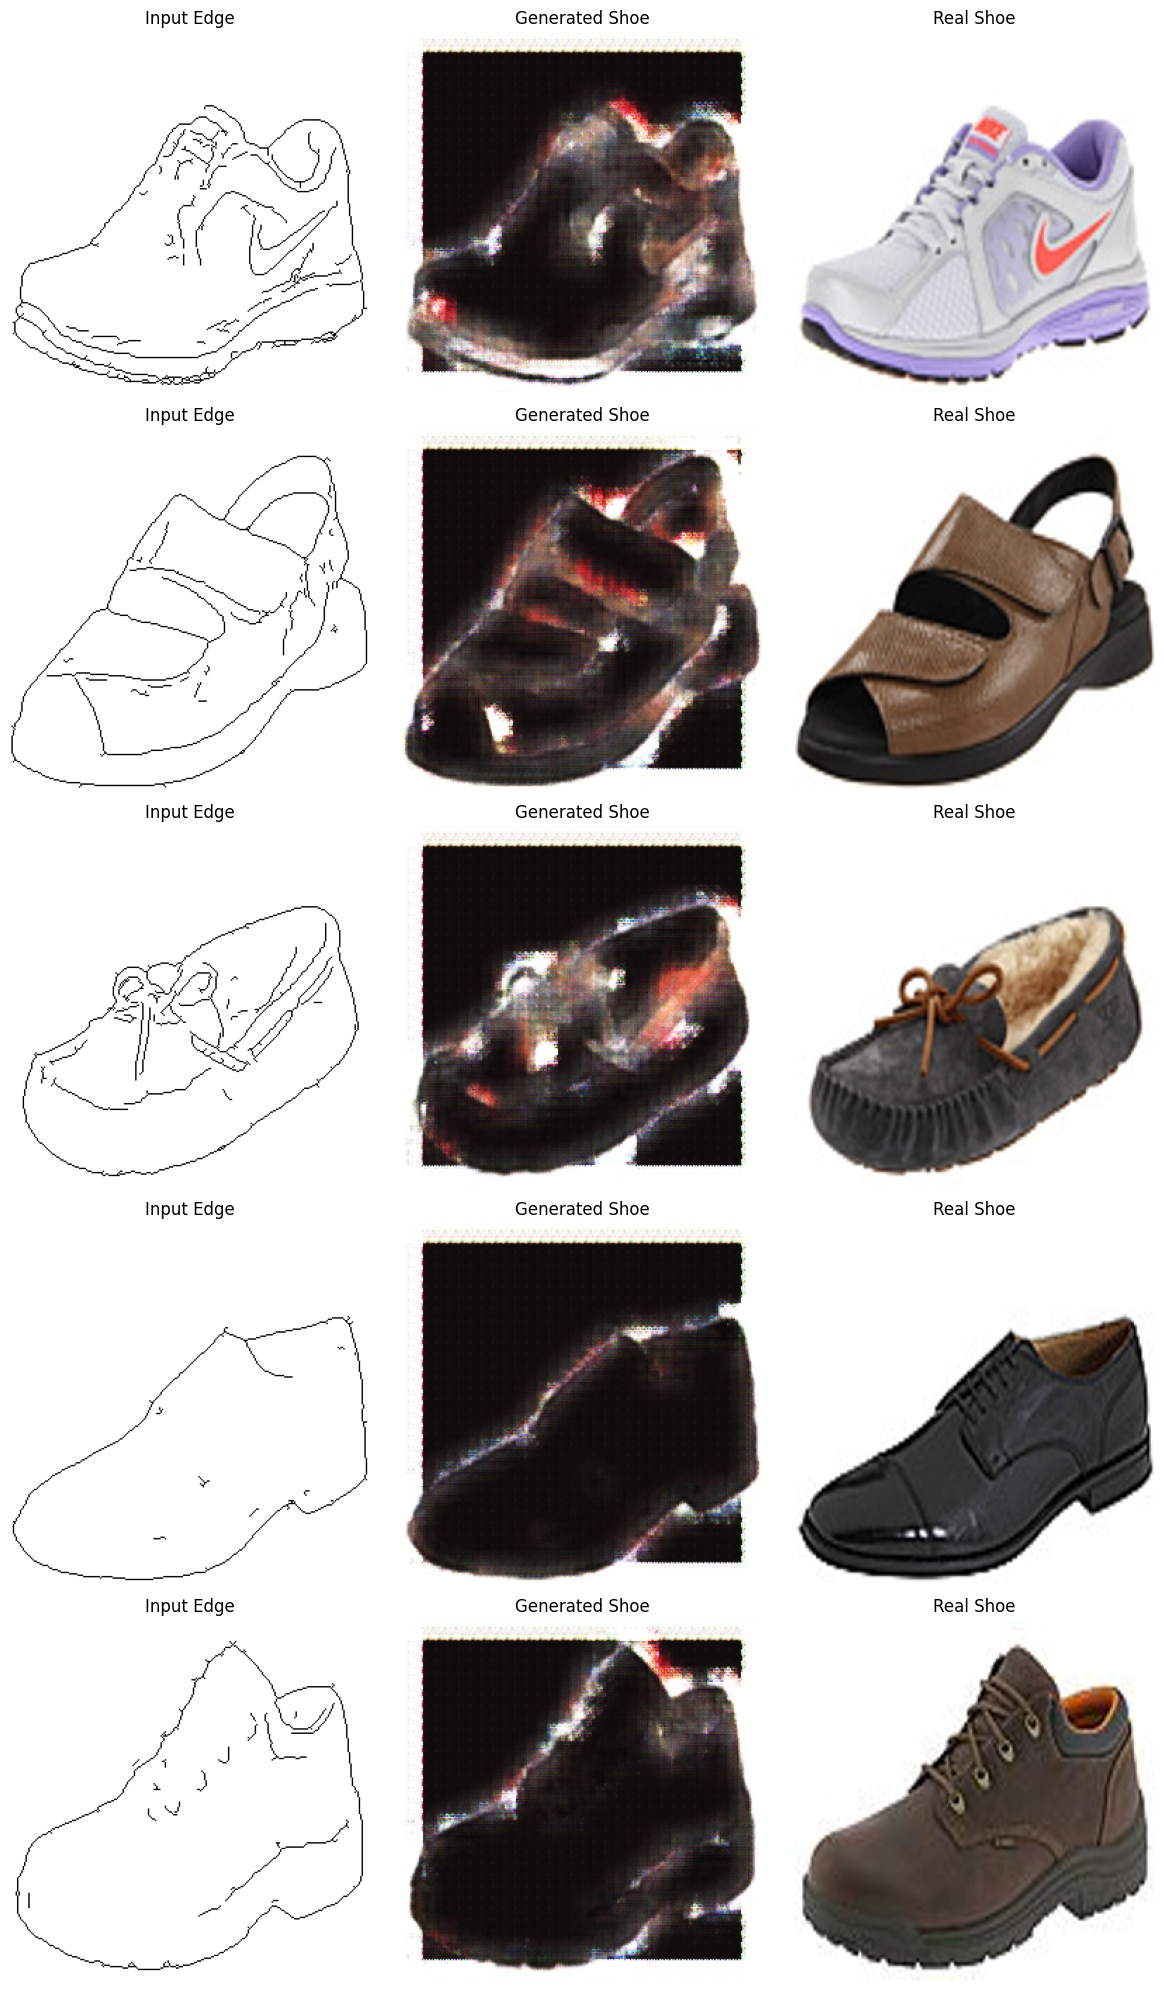

In [ ]:
def show_results(num=5):
    G.eval()
    with torch.no_grad():
        real_A, real_B = next(iter(dataloader))
        real_A = real_A[:num].to(device)
        fake_B = G(real_A)

        fig, axes = plt.subplots(num, 3, figsize=(12, 4*num))
        for i in range(num):
            # Convert tensors back to viewable images
            ax_in = (real_A[i].cpu().permute(1,2,0) * 0.5 + 0.5).numpy()
            ax_gen = (fake_B[i].cpu().permute(1,2,0) * 0.5 + 0.5).numpy()
            ax_real = (real_B[i].cpu().permute(1,2,0) * 0.5 + 0.5).numpy()

            axes[i, 0].imshow(ax_in)
            axes[i, 0].set_title("Input Edge")
            axes[i, 1].imshow(ax_gen)
            axes[i, 1].set_title("Generated Shoe")
            axes[i, 2].imshow(ax_real)
            axes[i, 2].set_title("Real Shoe")
            for ax in axes[i]: ax.axis('off')
        plt.tight_layout()
        plt.show()

show_results(num=5)